In [1]:
import numpy as np
import matplotlib.pyplot as plt
import EFC_learningfMRI.globals as gl
import PcmPy as pcm
import pandas as pd
from scipy.stats import linregress
import os
import itertools
import seaborn as sb
import statsmodels.formula.api as smf

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
df_sess_force                = pd.read_csv(os.path.join(gl.baseDir, gl.behavDir, 'force.session.success.tsv'), sep='\t')
dat_sess_fmri                = df_sess_force[df_sess_force.session.isin([3, 9, 23])].reset_index(drop=True)
trained_force                = dat_sess_fmri[dat_sess_fmri.chord=='trained'].reset_index(drop=True)
untrained_force              = dat_sess_fmri[dat_sess_fmri.chord=='untrained'].reset_index(drop=True)
diff_force                   = trained_force.copy()
diff_force                   = diff_force.merge(untrained_force, on=['subNum', 'session'])
diff_force['force_abs']      = diff_force.force_abs_x - diff_force.force_abs_y
diff_force['force_der']      = diff_force.force_der_x - diff_force.force_der_y
diff_force['force_der_peak'] = diff_force.force_der_peak_x - diff_force.force_der_peak_y

In [3]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
stat  = 'nanmean'
activation       = pd.read_csv(os.path.join(gl.baseDir, f'glm{glm}', 'ROI.activation.tsv'), sep='\t')
activation       = activation.groupby(['chord', 'session', 'sn', 'regionname', 'Hem']).mean(numeric_only=True).reset_index()
trained_act      = activation[activation.chord=='trained'].reset_index(drop=True)
untrained_act    = activation[activation.chord=='untrained'].reset_index(drop=True)
diff_act         = trained_act.copy()
diff_act         = diff_act.merge(untrained_act, on=['session', 'sn', 'regionname', 'Hem'])
diff_act['Diff'] = diff_act[f'{stat}_x'] - diff_act[f'{stat}_y']

   regionname  session  intercept    ci_low   ci_high
0         SMA        3   0.514695 -0.103339  1.132728
1         SMA        9  -0.909096 -1.421691 -0.396501
2         SMA       23  -2.486447 -3.907033 -1.065861
3         PMd        3   0.288802 -0.691291  1.268895
4         PMd        9  -2.492753 -3.578547 -1.406958
5         PMd       23  -4.537105 -6.366572 -2.707638
6         PMv        3  -0.061802 -0.391334  0.267731
7         PMv        9  -1.045868 -1.792917 -0.298818
8         PMv       23  -2.596318 -3.996929 -1.195706
9          M1        3  -0.180606 -0.912822  0.551610
10         M1        9  -0.985838 -2.157107  0.185432
11         M1       23  -2.590370 -3.952801 -1.227939
12         S1        3   0.047327 -0.753957  0.848611
13         S1        9  -1.714225 -3.312006 -0.116444
14         S1       23  -3.456547 -5.250342 -1.662752
15       SPLa        3   0.147766 -0.834061  1.129592
16       SPLa        9  -3.209081 -4.700184 -1.717978
17       SPLa       23  -6.7

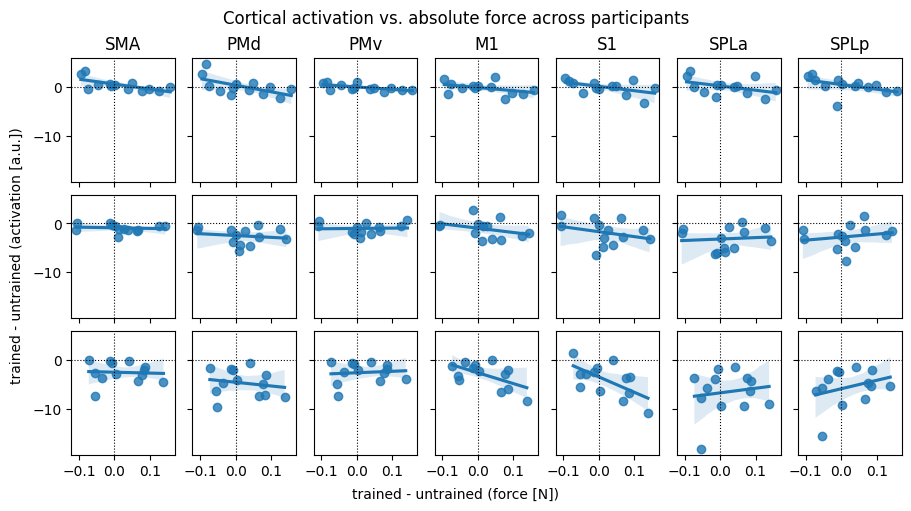

In [4]:
session   = diff_act.session.unique()
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, session)}

fig, axs = plt.subplots(len(session), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(session):
                ax = axs[s, r]
                y    = diff_act[(diff_act.Hem==H) & (diff_act.regionname==roi) & (diff_act.session==sess)].Diff.to_numpy()
                x    = diff_force[diff_force.session==sess].force_abs.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('trained - untrained (activation [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (force [N])', fontsize=10)

fig.suptitle('Cortical activation vs. absolute force across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
        })
intercepts = pd.DataFrame(records)
print(intercepts)

plt.show()

   regionname  session  intercept     ci_low   ci_high
0          M1        3  -0.294606  -1.090619  0.501406
1          M1        9  -0.345349  -2.001637  1.310939
2          M1       23  -3.150966  -5.265023 -1.036908
3         PMd        3  -0.074335  -1.034906  0.886235
4         PMd        9  -1.558651  -2.877374 -0.239928
5         PMd       23  -4.434347  -6.763262 -2.105432
6         PMv        3  -0.180716  -0.553296  0.191864
7         PMv        9  -0.804646  -1.868118  0.258825
8         PMv       23  -2.173669  -3.906780 -0.440557
9          S1        3  -0.174046  -1.010576  0.662484
10         S1        9  -0.611028  -2.737250  1.515195
11         S1       23  -3.504878  -6.306183 -0.703573
12        SMA        3   0.266198  -0.431509  0.963906
13        SMA        9  -0.429765  -1.027943  0.168414
14        SMA       23  -2.470420  -4.261813 -0.679028
15       SPLa        3  -0.109011  -1.019512  0.801491
16       SPLa        9  -2.805281  -4.952098 -0.658463
17       S

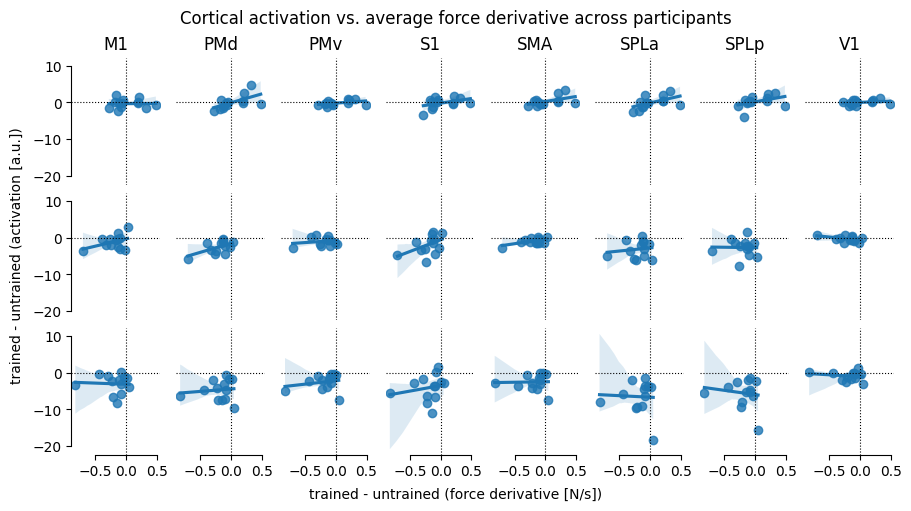

In [16]:
session   = diff_act.session.unique()
rois      = diff_act.regionname.unique()
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, session)}

fig, axs = plt.subplots(len(session), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(session):
                ax = axs[s, r]
                y    = diff_act[(diff_act.Hem==H) & (diff_act.regionname==roi) & (diff_act.session==sess)].Diff.to_numpy()
                x    = diff_force[diff_force.session==sess].force_der.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')


for r in range(len(rois)):
        for s in range(len(session)):
                ax = axs[s, r]
                sb.despine(ax=ax, trim=True, bottom=s < len(session)-1, left=r > 0)
                ax.tick_params(bottom=s == len(session)-1, left=r == 0)

fig.supylabel('trained - untrained (activation [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (force derivative [N/s])', fontsize=10)

fig.suptitle('Cortical activation vs. average force derivative across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
        })
intercepts = pd.DataFrame(records)
print(intercepts)

fig.savefig('figures/force_der_intercept.pdf')

plt.show()

In [12]:
s

2

   regionname  session  intercept    ci_low   ci_high
0          M1        3  -0.284701 -1.086305  0.516903
1          M1        9  -1.021391 -2.331420  0.288639
2          M1       23  -2.719392 -4.379749 -1.059035
3         PMd        3  -0.035109 -1.185343  1.115125
4         PMd        9  -2.316921 -3.420851 -1.212991
5         PMd       23  -4.632542 -6.559286 -2.705798
6         PMv        3  -0.157262 -0.572978  0.258454
7         PMv        9  -0.960122 -1.747151 -0.173094
8         PMv       23  -2.640428 -4.088718 -1.192138
9          S1        3  -0.133158 -1.048440  0.782124
10         S1        9  -1.876391 -3.653154 -0.099628
11         S1       23  -3.866450 -6.194116 -1.538783
12        SMA        3   0.289422 -0.497776  1.076620
13        SMA        9  -0.685380 -1.070948 -0.299811
14        SMA       23  -2.491151 -3.965657 -1.016646
15       SPLa        3  -0.064222 -1.119047  0.990603
16       SPLa        9  -3.275500 -4.856892 -1.694108
17       SPLa       23  -6.4

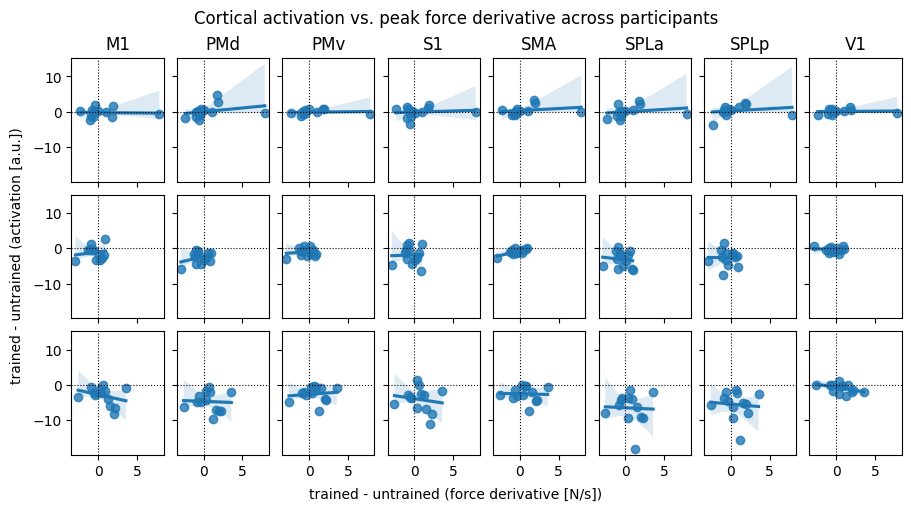

In [38]:
session   = diff_act.session.unique()
rois      = diff_act.regionname.unique()
lin_model = {(roi, sess): [] for roi, sess in itertools.product(rois, session)}

fig, axs = plt.subplots(len(session), len(rois), constrained_layout=True, sharex=True, sharey=True, figsize=(9, 5))

for r, roi in enumerate(rois):
        for s, sess in enumerate(session):
                ax = axs[s, r]
                y    = diff_act[(diff_act.Hem==H) & (diff_act.regionname==roi) & (diff_act.session==sess)].Diff.to_numpy()
                x    = diff_force[diff_force.session==sess].force_der_peak.to_numpy()
                data = pd.DataFrame(np.c_[x, y], columns=['force', 'neural'])

                lin_model[(roi, sess)] = smf.ols('y~x', data=data).fit()

                sb.regplot(data, x='force', y='neural', ax=ax)

                ax.set_title(roi if s==0 else None)
                ax.set_ylabel(None)
                ax.set_xlabel(None)
                ax.axhline(0, color='k', lw=.8, ls=':')
                ax.axvline(0, color='k', lw=.8, ls=':')

fig.supylabel('trained - untrained (activation [a.u.])', fontsize=10)
fig.supxlabel('trained - untrained (force derivative [N/s])', fontsize=10)

fig.suptitle('Cortical activation vs. peak force derivative across participants')

records = []
for (roi, sess), res in lin_model.items():
        lo, hi = res.conf_int().loc['Intercept']
        records.append({
                'regionname': roi,
                'session':    sess,
                'intercept':  res.params['Intercept'],
                'ci_low':     lo,
                'ci_high':    hi,
        })
intercepts = pd.DataFrame(records)
print(intercepts)

plt.show()